#### *Se cargan los tres datasets y se muestran las primeras filas*

In [19]:
import pandas as pd
from IPython.display import display, Markdown
import io
import sys
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

In [2]:
# Cargar los tres datasets
caracteristicas_df = pd.read_csv("../src/Caracteristicas_Equipos.csv")
ordenes_df = pd.read_csv("../src/Historicos_Ordenes.csv")
condiciones_df = pd.read_csv("../src/Registros_Condiciones.csv")

# Mostrar las primeras filas de cada dataset para revisar su estructura
# Mostrar características
display(Markdown("### 🛠️ Características de Equipos"))
display(caracteristicas_df.head())

# Mostrar órdenes históricas
display(Markdown("### 📋 Históricos de Órdenes"))
display(ordenes_df.head())

# Mostrar condiciones operativas
display(Markdown("### 📊 Registros de Condiciones"))
display(condiciones_df.head())


### 🛠️ Características de Equipos

,ID_Equipo,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision
0,1,Bomba,Fabricante_A,Modelo_8,432,657
1,2,Generador,Fabricante_B,Modelo_2,393,522
2,3,Motor,Fabricante_C,Modelo_7,398,885
3,4,Bomba,Fabricante_D,Modelo_4,121,668
4,5,Generador,Fabricante_C,Modelo_7,51,958


### 📋 Históricos de Órdenes

,ID_Orden,ID_Equipo,Fecha,Tipo_Mantenimiento,Costo_Mantenimiento,Duracion_Horas,Ubicacion
0,1,382,2021-01-01,Correctivo,4331,16,Ubicacion_A
1,2,350,2021-01-01,Correctivo,2927,12,Ubicacion_A
2,3,302,2021-01-02,Correctivo,3863,6,Ubicacion_B
3,4,55,2021-01-02,Correctivo,1556,2,Ubicacion_D
4,5,89,2021-01-02,Correctivo,3680,17,Ubicacion_B


### 📊 Registros de Condiciones

,ID_Registro,ID_Equipo,Fecha,Temperatura_C,Vibracion_mm_s,Horas_Operativas
0,1,1,2021-01-01,36.587104,4.430381,579
1,2,106,2021-01-01,53.268051,0.534711,577
2,3,446,2021-01-01,47.176472,7.116958,263
3,4,107,2021-01-01,76.404597,2.696906,491
4,5,108,2021-01-01,50.729327,6.996772,589


In [3]:
def print_info(df, titulo):
    buffer = io.StringIO()
    df.info(buf=buffer)
    info_str = buffer.getvalue()
    display(Markdown(f"### {titulo}"))
    display(Markdown(f"```\n{info_str}\n```"))

# Mostrar info de cada DataFrame
print_info(caracteristicas_df, "🛠️ Info: Características de Equipos")
print_info(ordenes_df, "📋 Info: Históricos de Órdenes")
print_info(condiciones_df, "📊 Info: Registros de Condiciones")


### 🛠️ Info: Características de Equipos

```
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   ID_Equipo                    500 non-null    int64 
 1   Tipo_Equipo                  500 non-null    object
 2   Fabricante                   500 non-null    object
 3   Modelo                       500 non-null    object
 4   Potencia_kW                  500 non-null    int64 
 5   Horas_Recomendadas_Revision  500 non-null    int64 
dtypes: int64(3), object(3)
memory usage: 23.6+ KB

```

### 📋 Info: Históricos de Órdenes

```
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31866 entries, 0 to 31865
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID_Orden             31866 non-null  int64 
 1   ID_Equipo            31866 non-null  int64 
 2   Fecha                31866 non-null  object
 3   Tipo_Mantenimiento   31866 non-null  object
 4   Costo_Mantenimiento  31866 non-null  int64 
 5   Duracion_Horas       31866 non-null  int64 
 6   Ubicacion            31866 non-null  object
dtypes: int64(4), object(3)
memory usage: 1.7+ MB

```

### 📊 Info: Registros de Condiciones

```
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730500 entries, 0 to 730499
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   ID_Registro       730500 non-null  int64  
 1   ID_Equipo         730500 non-null  int64  
 2   Fecha             730500 non-null  object 
 3   Temperatura_C     730500 non-null  float64
 4   Vibracion_mm_s    730500 non-null  float64
 5   Horas_Operativas  730500 non-null  int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 33.4+ MB

```

#### *Vamos a crear la columna frecuencia_correctivo en ordenes_df, que calculará para cada equipo (ID_Equipo) la media quincenal (cada dos semanas) de órdenes de mantenimiento correctivo (Tipo_Mantenimiento == "correctivo"), utilizando la columna Fecha.*

In [4]:
# Asegúrate de que la columna Fecha esté en formato datetime
ordenes_df['Fecha'] = pd.to_datetime(ordenes_df['Fecha'])

# Filtramos solo los mantenimientos correctivos
correctivos_df = ordenes_df[ordenes_df['Tipo_Mantenimiento'].str.lower() == 'correctivo'].copy()

# Creamos una columna con el rango quincenal (cada 14 días)
correctivos_df['Periodo_Quincenal'] = correctivos_df['Fecha'].dt.to_period('14D')

# Contamos correctivos por equipo y periodo
frecuencia_quincenal = (
    correctivos_df
    .groupby(['ID_Equipo', 'Periodo_Quincenal'])
    .size()
    .reset_index(name='conteo_correctivos')
)

# Calculamos la media de correctivos quincenal por equipo
media_correctivos = (
    frecuencia_quincenal
    .groupby('ID_Equipo')['conteo_correctivos']
    .mean()
    .reset_index(name='frecuencia_correctivo')
)

# Unimos esa media al dataframe original
ordenes_df = ordenes_df.merge(media_correctivos, on='ID_Equipo', how='left')


In [5]:
display(Markdown("### 📋 DataFrame con `frecuencia_correctivo` añadida"))
display(ordenes_df.head(500))

### 📋 DataFrame con `frecuencia_correctivo` añadida

,ID_Orden,ID_Equipo,Fecha,Tipo_Mantenimiento,Costo_Mantenimiento,Duracion_Horas,Ubicacion,frecuencia_correctivo
0,1,382,2021-01-01,Correctivo,4331,16,Ubicacion_A,1.0
1,2,350,2021-01-01,Correctivo,2927,12,Ubicacion_A,1.0
2,3,302,2021-01-02,Correctivo,3863,6,Ubicacion_B,1.0
3,4,55,2021-01-02,Correctivo,1556,2,Ubicacion_D,1.0
4,5,89,2021-01-02,Correctivo,3680,17,Ubicacion_B,1.0
...,...,...,...,...,...,...,...,...
495,496,86,2021-02-02,Preventivo,745,1,Ubicacion_A,1.0
496,497,143,2021-02-02,Preventivo,672,1,Ubicacion_A,1.0
497,498,437,2021-02-02,Preventivo,409,1,Ubicacion_A,1.0
498,499,431,2021-02-02,Preventivo,495,2,Ubicacion_D,1.0


#### *Para hacer un merge entre caracteristicas_df y ordenes_df, la columna común más probable es ID_Equipo, ya que ambas deben contener información de los equipos.*

In [6]:
# Hacemos merge por ID_Equipo
ordenes_completo_df = ordenes_df.merge(caracteristicas_df, on='ID_Equipo', how='left')

In [7]:
display(Markdown("### 🔗 `ordenes_completo_df`: Resultado del merge entre `ordenes_df` y `caracteristicas_df`"))
display(ordenes_completo_df.head())

### 🔗 `ordenes_completo_df`: Resultado del merge entre `ordenes_df` y `caracteristicas_df`

,ID_Orden,ID_Equipo,Fecha,Tipo_Mantenimiento,Costo_Mantenimiento,Duracion_Horas,Ubicacion,frecuencia_correctivo,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision
0,1,382,2021-01-01,Correctivo,4331,16,Ubicacion_A,1.0,Bomba,Fabricante_A,Modelo_10,281,634
1,2,350,2021-01-01,Correctivo,2927,12,Ubicacion_A,1.0,Generador,Fabricante_A,Modelo_9,127,608
2,3,302,2021-01-02,Correctivo,3863,6,Ubicacion_B,1.0,Generador,Fabricante_C,Modelo_9,331,701
3,4,55,2021-01-02,Correctivo,1556,2,Ubicacion_D,1.0,Compresor,Fabricante_B,Modelo_9,71,660
4,5,89,2021-01-02,Correctivo,3680,17,Ubicacion_B,1.0,Compresor,Fabricante_D,Modelo_3,281,750


#### *Vamos a crear en condiciones_df una columna llamada frecuencia_anomalia, que indique la media quincenal de anomalías por ID_Equipo, usando la columna Fecha. Cada fila representa una anomalía detectada, así que vamos a contar cuántas hay cada dos semanas por equipo, y luego calcular la media.*

In [8]:
# Aseguramos el tipo datetime
condiciones_df['Fecha'] = pd.to_datetime(condiciones_df['Fecha'])

# Crear una lista para guardar los resultados por equipo
lista_resultados = []

# Agrupar por equipo y aplicar resample individualmente
for equipo_id, grupo in condiciones_df.groupby('ID_Equipo'):
    grupo = grupo.set_index('Fecha').sort_index()
    
    # Contamos la cantidad de anomalías por cada 14 días
    conteo = grupo.resample('14D').size()
    
    # Calculamos la media para este equipo
    media_quincenal = conteo.mean()
    
    # Guardamos el resultado
    lista_resultados.append({'ID_Equipo': equipo_id, 'frecuencia_anomalia': media_quincenal})

# Convertimos a DataFrame
frecuencia_anomalia_df = pd.DataFrame(lista_resultados)

# Hacemos merge limpio con condiciones_df
condiciones_df = condiciones_df.drop(columns=[col for col in condiciones_df.columns if 'frecuencia_anomalia' in col], errors='ignore')
condiciones_df = condiciones_df.merge(frecuencia_anomalia_df, on='ID_Equipo', how='left')


In [9]:
display(Markdown("### ⚠️ DataFrame con columna `frecuencia_anomalia` añadida"))
display(condiciones_df.head(500))

### ⚠️ DataFrame con columna `frecuencia_anomalia` añadida

,ID_Registro,ID_Equipo,Fecha,Temperatura_C,Vibracion_mm_s,Horas_Operativas,frecuencia_anomalia
0,1,1,2021-01-01,36.587104,4.430381,579,13.914286
1,2,106,2021-01-01,53.268051,0.534711,577,13.914286
2,3,446,2021-01-01,47.176472,7.116958,263,13.914286
3,4,107,2021-01-01,76.404597,2.696906,491,13.914286
4,5,108,2021-01-01,50.729327,6.996772,589,13.914286
...,...,...,...,...,...,...,...
495,496,384,2021-01-01,65.057930,8.697510,171,13.914286
496,497,226,2021-01-01,87.706190,8.178038,511,13.914286
497,498,388,2021-01-01,59.433401,7.663646,69,13.914286
498,499,2,2021-01-01,90.809284,7.934667,708,13.914286


- Tienes **500 equipos**.
- Todos los equipos tienen **exactamente el mismo rango de fechas**: del `2021-01-01` al `2024-12-31` → eso son **1461 días**, o sea **104.36 quincenas**.
- Y el DataFrame tiene **730,500 filas**, lo que equivale exactamente a **1461 días × 500 equipos**, es decir: **1 fila por equipo por día**.

Entonces:  
🔁 Cada equipo tiene **una anomalía por día**, sin falta.  
👉 Por eso, **todos tienen exactamente 13.91428571 anomalías cada 14 días**:


#### *1461 anomalías\104.36 quincenas approx 13.91*


#### *Para hacer un merge entre caracteristicas_df y condiciones_df, también vamos a usar ID_Equipo como clave común.*

In [10]:
# Realizamos el merge por ID_Equipo
condiciones_completo_df = condiciones_df.merge(caracteristicas_df, on='ID_Equipo', how='left')

In [11]:
display(Markdown("### 🔗 `condiciones_completo_df`: Resultado del merge entre `condiciones_df` y `caracteristicas_df`"))
display(condiciones_completo_df.head())

### 🔗 `condiciones_completo_df`: Resultado del merge entre `condiciones_df` y `caracteristicas_df`

,ID_Registro,ID_Equipo,Fecha,Temperatura_C,Vibracion_mm_s,Horas_Operativas,frecuencia_anomalia,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision
0,1,1,2021-01-01,36.587104,4.430381,579,13.914286,Bomba,Fabricante_A,Modelo_8,432,657
1,2,106,2021-01-01,53.268051,0.534711,577,13.914286,Motor,Fabricante_D,Modelo_3,448,801
2,3,446,2021-01-01,47.176472,7.116958,263,13.914286,Generador,Fabricante_C,Modelo_2,95,561
3,4,107,2021-01-01,76.404597,2.696906,491,13.914286,Compresor,Fabricante_A,Modelo_7,195,748
4,5,108,2021-01-01,50.729327,6.996772,589,13.914286,Compresor,Fabricante_A,Modelo_9,181,560


#### *Crear la columna tiempo_para_fallo en condiciones_completo_df, calculando la diferencia entre: Horas_Recomendadas_Revision - Horas_Operativas*

In [12]:
# Crear columna como la diferencia entre horas recomendadas y operativas
condiciones_completo_df['tiempo_para_fallo'] = condiciones_completo_df['Horas_Recomendadas_Revision'] - condiciones_completo_df['Horas_Operativas']

In [13]:
display(Markdown("### ⏳ `tiempo_para_fallo` añadido a `condiciones_completo_df`"))
display(condiciones_completo_df.head(500))

### ⏳ `tiempo_para_fallo` añadido a `condiciones_completo_df`

,ID_Registro,ID_Equipo,Fecha,Temperatura_C,Vibracion_mm_s,Horas_Operativas,frecuencia_anomalia,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision,tiempo_para_fallo
0,1,1,2021-01-01,36.587104,4.430381,579,13.914286,Bomba,Fabricante_A,Modelo_8,432,657,78
1,2,106,2021-01-01,53.268051,0.534711,577,13.914286,Motor,Fabricante_D,Modelo_3,448,801,224
2,3,446,2021-01-01,47.176472,7.116958,263,13.914286,Generador,Fabricante_C,Modelo_2,95,561,298
3,4,107,2021-01-01,76.404597,2.696906,491,13.914286,Compresor,Fabricante_A,Modelo_7,195,748,257
4,5,108,2021-01-01,50.729327,6.996772,589,13.914286,Compresor,Fabricante_A,Modelo_9,181,560,-29
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,384,2021-01-01,65.057930,8.697510,171,13.914286,Motor,Fabricante_A,Modelo_1,208,773,602
496,497,226,2021-01-01,87.706190,8.178038,511,13.914286,Compresor,Fabricante_C,Modelo_10,436,672,161
497,498,388,2021-01-01,59.433401,7.663646,69,13.914286,Motor,Fabricante_C,Modelo_6,474,543,474
498,499,2,2021-01-01,90.809284,7.934667,708,13.914286,Generador,Fabricante_B,Modelo_2,393,522,-186


In [17]:
# Crear un target binario: fallo en menos de 360 horas
condiciones_completo_df['target_fallo'] = (condiciones_completo_df['tiempo_para_fallo'] < 360).astype(int)

#### *Seleccionar características numéricas*

In [18]:
# Eliminar columnas no útiles
columnas_excluir = ['ID_Equipo', 'Fecha', 'target_fallo','ID_Registro']
features = condiciones_completo_df.select_dtypes(include=['number']).drop(columns=columnas_excluir, errors='ignore')
X = features.copy()
y = condiciones_completo_df['target_fallo']

#### *Entrenar Random Forest y extraer importancia*

/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


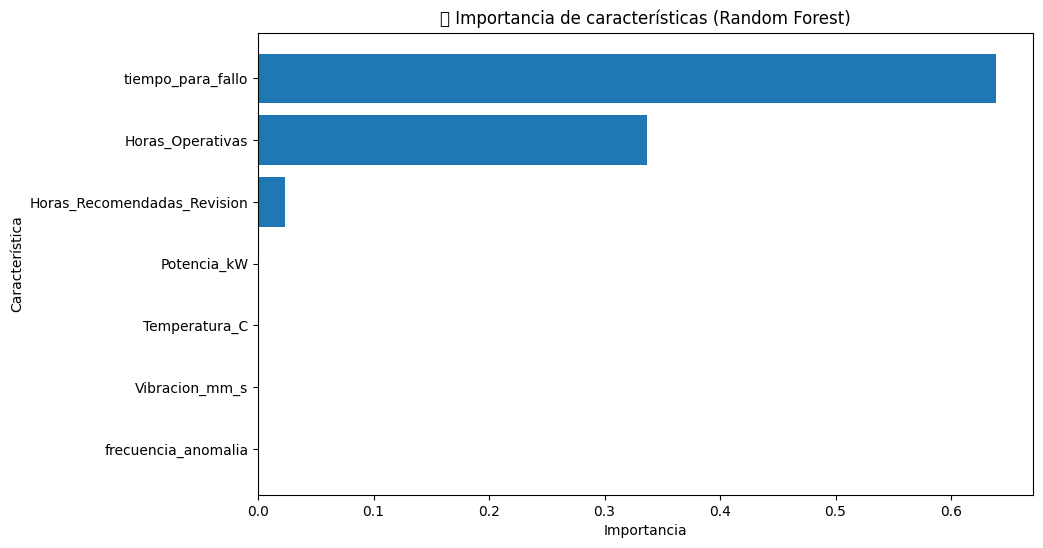

In [20]:
# Entrenamos modelo simple
modelo = RandomForestClassifier(random_state=42)
modelo.fit(X, y)

# Importancia
importancias = modelo.feature_importances_
caracteristicas = X.columns

# Visualizar
import pandas as pd
importancias_df = pd.DataFrame({
    'feature': caracteristicas,
    'importance': importancias
}).sort_values(by='importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importancias_df['feature'], importancias_df['importance'])
plt.gca().invert_yaxis()
plt.title('🔍 Importancia de características (Random Forest)')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.show()
